In [31]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sb

In [32]:
soy_raw = pd.read_csv('soy_raw.csv')
sm = pd.read_csv('sm.csv')
vod = pd.read_csv('vod.csv')

In [33]:
# Process the daily soil moisture and VOD data into a 4-month mean, 90th percentile, and 10th percentile.

sm_data = pd.DataFrame({
    'sm_mean': sm.mean(axis=1),
    'sm_q10': sm.quantile(0.1, axis=1),
    'sm_q90': sm.quantile(0.9, axis=1)
})

vod_data = pd.DataFrame({
    'vod_mean': vod.mean(axis=1),
    'vod_q10': vod.quantile(0.1,axis=1),
    'vod_q90': vod.quantile(0.9,axis=1)
})

sm_data.head()

,sm_mean,sm_q10,sm_q90
0,0.160216,0.100764,0.214964
1,0.197299,0.147242,0.230992
2,0.172573,0.121811,0.221127
3,0.220197,0.166704,0.259562
4,0.179592,0.107898,0.252813


In [34]:
# Combine all values into one final dataframe

soy_data = pd.concat([soy_raw, sm_data, vod_data],axis=1)
soy_data.head()

,yield,tmax_apr,tmax_may,tmax_jun,tmax_jul,prcp_apr,prcp_may,prcp_jun,prcp_jul,sm_mean,sm_q10,sm_q90,vod_mean,vod_q10,vod_q90
0,4.194062,26.944885,31.191715,33.047821,34.505318,197.227264,133.386368,137.943176,186.301132,0.160216,0.100764,0.214964,0.393141,0.337151,0.491918
1,7.157392,19.691486,23.379566,27.378342,28.906879,64.965958,128.230209,273.581238,253.794022,0.197299,0.147242,0.230992,0.279009,0.227866,0.314052
2,9.170855,16.248007,21.388821,25.129047,27.099064,81.545547,136.449112,167.224213,122.737778,0.172573,0.121811,0.221127,0.227040,0.173746,0.279634
3,7.172860,19.613501,23.488871,27.322500,28.711775,59.570000,123.529999,280.100006,241.889999,0.220197,0.166704,0.259562,0.317403,0.265927,0.364536
4,9.197968,17.863222,22.617496,26.069649,27.146734,89.199593,138.738678,218.345963,111.989548,0.179592,0.107898,0.252813,0.206323,0.144299,0.274184


<Axes: >

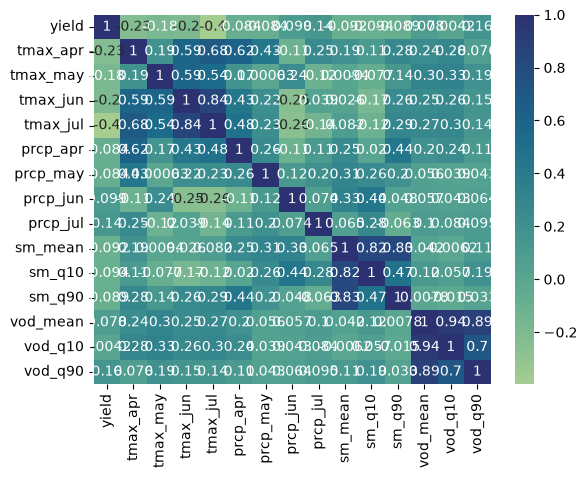

In [39]:
# jj

soy_corr_mat = soy_data.corr(numeric_only=True)
sb.heatmap(soy_corr_mat, annot=True, cmap='crest')